In [ ]:
import torch # главная библиотека, в торче лежит всё
from torch.utils.data import Dataset, DataLoader # Dataset - хранилище данных, DataLoader - загрузчик, через который мы будем получать данные
from torch.optim import AdamW # наш оптимизатор, он смотрит на ошибку и меняет веса, чтобы сеть лучше работала
from torch.optim import Adagrad
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, confusion_matrix,
                           classification_report, roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns

import torch.nn as nn
from torch.amp import GradScaler
from torch.utils.data import random_split
from sklearn.preprocessing import TargetEncoder

In [ ]:
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

get_device()

device(type='cuda')

In [ ]:
data = pd.read_csv('telescope_data.csv',index_col='Unnamed: 0')
data['class'] = np.where(data['class'] == 'g', 1, 0)
data

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1
...,...,...,...,...,...,...,...,...,...,...,...
19015,21.3846,10.9170,2.6161,0.5857,0.3934,15.2618,11.5245,2.8766,2.4229,106.8258,0
19016,28.9452,6.7020,2.2672,0.5351,0.2784,37.0816,13.1853,-2.9632,86.7975,247.4560,0
19017,75.4455,47.5305,3.4483,0.1417,0.0549,-9.3561,41.0562,-9.4662,30.2987,256.5166,0
19018,120.5135,76.9018,3.9939,0.0944,0.0683,5.8043,-93.5224,-63.8389,84.6874,408.3166,0


In [ ]:
class TelescopeData(Dataset):
    def __init__(self, x, y):
        if isinstance(x, pd.DataFrame):
            self.x = x.reset_index(drop = True).values.astype(np.float32)
        elif isinstance(x, np.ndarray):
            self.x = x.astype(np.float32)
        elif isinstance(x , torch.tensor):
            self.x = x.numpy().astype(np.float32)
        else:
            self.x = np.array(x).astype(np.float32)

        if isinstance(y, (pd.Series ,pd.DataFrame)):
            self.y = y.reset_index(drop = True).values.astype(np.float32)
        elif isinstance(y, np.ndarray):
            self.y = y.astype(np.float32)
        elif isinstance(y , torch.tensor):
            self.y = y.numpy().astype(np.float32)
        else:
            self.y = np.array(y).astype(np.float32)

        if len(self.y.shape) == 1:
            self.y = self.y.reshape(-1, 1)

    def __getitem__(self, index):
        x = self.x[index]
        y = self.y[index]

        x = torch.from_numpy(x).float()
        y = torch.from_numpy(np.array([y])).float()

        return x,y
    
    def __len__(self):
        return len(self.x)

In [ ]:
class AutoEncoder(nn.Module):
    def __init__(self, input_dim = 10, latent_dim = 4):
        super(AutoEncoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512,1024),
            nn.Tanh(),
            nn.Linear(1024, 256),
            nn.Tanh(),
            nn.Linear(256, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.Tanh(),
            nn.Linear(256, 1024),
            nn.Tanh(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim)
        )
    def encode(self, x):
        return self.encoder(x)
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        z = self.encode(x)
        reconst = self.decode(z)
        return reconst

In [ ]:
class myModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_1 = nn.Linear(10, 128)
        self.linear_2 = nn.Linear(128, 512)
        self.linear_3 = nn.Linear(512, 1024)
        self.linear_4 = nn.Linear(1024, 512)
        self.linear_5 = nn.Linear(512, 128)
        self.linear_6 = nn.Linear(128, 1)

        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()

    def forward(self,x):
        out = self.linear_1(x)
        out = self.tanh(out)
        out = self.linear_2(out)
        out = self.tanh(out)
        out = self.linear_3(out)
        out = self.relu(out)
        out = self.linear_4(out)
        out = self.relu(out)
        out = self.linear_5(out)
        out = self.relu(out)
        out = self.linear_6(out)

        return out.unsqueeze(dim = -1)


In [ ]:
class myModel_with_ae(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_1 = nn.Linear(4, 128)
        self.linear_2 = nn.Linear(128, 512)
        self.linear_3 = nn.Linear(512, 1024)
        self.linear_4 = nn.Linear(1024, 512)
        self.linear_5 = nn.Linear(512, 128)
        self.linear_6 = nn.Linear(128, 1)

        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()

    def forward(self,x):
        out = self.linear_1(x)
        out = self.tanh(out)
        out = self.linear_2(out)
        out = self.tanh(out)
        out = self.linear_3(out)
        out = self.relu(out)
        out = self.linear_4(out)
        out = self.relu(out)
        out = self.linear_5(out)
        out = self.relu(out)
        out = self.linear_6(out)

        return out.unsqueeze(dim = -1)


In [ ]:
class Trainer():
    def __init__(self, model, device, optimizer, train_loader, test_loader, weight_class_0):
        self.device = torch.device(device)
        self.model = model.to(device)
        self.optimizer = optimizer
        self.train_loader = train_loader 
        self.test_loader = test_loader
        self.weight_class_0 = weight_class_0

        self.use_amp = (self.device.type == "cuda")
        if self.use_amp and torch.cuda.is_bf16_supported():
            self.dtype = torch.bfloat16
        else:
            self.dtype = torch.float16

        self.criterion = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([weight_class_0]).to(DEVICE)
)
        self.scaler = GradScaler(
            enabled=(self.use_amp and self.dtype == torch.float16)
        )

    def train_epoch(self):
        self.model.train()
        train_loss = 0.0
        device_type = self.device.type
        for x, target in self.train_loader:
            x = x.to(self.device)
            target = target.to(self.device)
            self.optimizer.zero_grad()

            with torch.autocast(
                device_type = device_type,
                dtype = self.dtype,
                enabled = self.use_amp
            ):
                out = self.model(x)
                loss = self.criterion(out, target)

            self.scaler.scale(loss).backward()

            self.scaler.unscale_(self.optimizer)
            nn.utils.clip_grad_norm_(self.model.parameters(), max_norm = 1.0)

            self.scaler.step(self.optimizer)
            self.scaler.update()

            train_loss += loss.item()

        return train_loss / len(self.train_loader)
        
    @torch.no_grad()
    def val_epoch(self):
        self.model.eval()
        val_loss = 0.0
        device_type = self.device.type
        for x, target in self.test_loader:
            x = x.to(self.device)
            target = target.to(self.device)
            self.optimizer.zero_grad()
            with torch.autocast(
                device_type=device_type,
                dtype=self.dtype,
                enabled=self.use_amp,
            ):
                outputs = self.model(x)
                loss = self.criterion(outputs, target)
            val_loss = loss.item()
        return val_loss/len(self.train_loader)

In [ ]:
y = data['class']
X = data.drop('class', axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

train_ds = TelescopeData(x_train_scaled, y_train)
test_ds = TelescopeData(x_test_scaled, y_test)

train_loader = DataLoader(train_ds, batch_size=1024)
test_loader = DataLoader(test_ds, batch_size=1024)

epoch = 0 loss = 0.47960085272789
epoch = 1 loss = 0.20707574486732483
epoch = 2 loss = 0.1530133197704951
epoch = 3 loss = 0.12444963157176972
epoch = 4 loss = 0.10952159216006598
epoch = 5 loss = 0.10582220007975897
epoch = 6 loss = 0.09706148952245712
epoch = 7 loss = 0.0933156708876292
epoch = 8 loss = 0.09059641708930334
epoch = 9 loss = 0.08862176289161046
epoch = 10 loss = 0.08506570706764857
epoch = 11 loss = 0.08156212071577708
epoch = 12 loss = 0.07976395835479101
epoch = 13 loss = 0.0794257308046023
epoch = 14 loss = 0.07867351373036703
epoch = 15 loss = 0.07849060545365015
epoch = 16 loss = 0.07826466113328934
epoch = 17 loss = 0.07605147063732147
epoch = 18 loss = 0.07484606256087621
epoch = 19 loss = 0.07325728336970011
epoch = 20 loss = 0.07165150245030721
epoch = 21 loss = 0.07016966839631399
epoch = 22 loss = 0.06987008651097616
epoch = 23 loss = 0.06952962776025136
epoch = 24 loss = 0.06943268279234568
epoch = 25 loss = 0.06893086036046346
epoch = 26 loss = 0.06950323

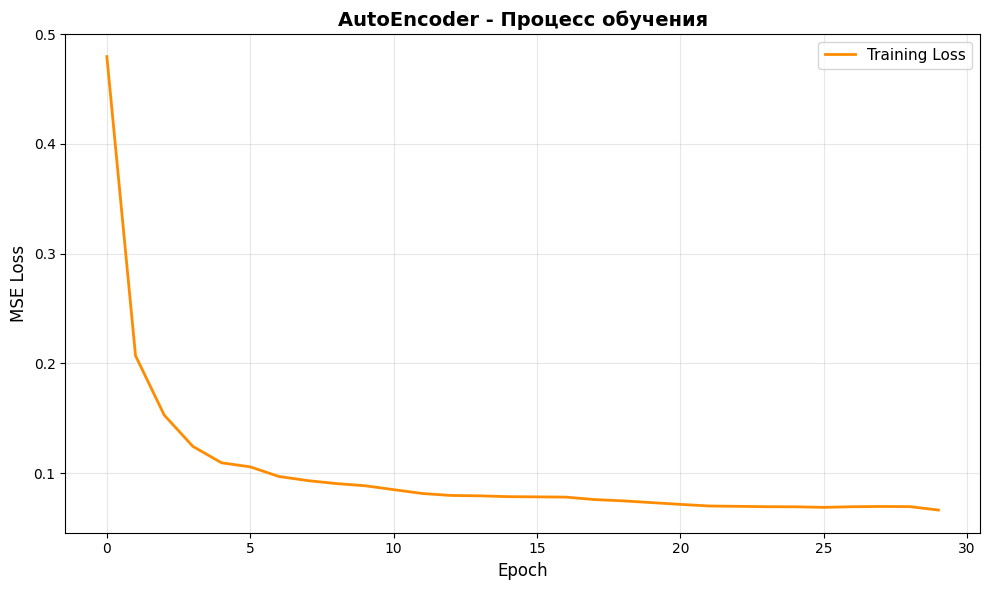

In [ ]:
model_ae = AutoEncoder(input_dim = 10, latent_dim = 4).to(DEVICE)
optimizer = AdamW(model_ae.parameters(), lr=0.001)
criterion = nn.MSELoss()

epoch = 30
losses = [] 

for i in range(epoch):
    model_ae.train()
    train_loss = 0.0

    for x,_ in train_loader:
        x = x.to(DEVICE)

        optimizer.zero_grad()
        outputs = model_ae(x)
        loss = criterion(outputs, x)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model_ae.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
        
    
    train_loss /= len(train_loader)
    losses.append(train_loss)
    print(f'epoch = {i} loss = {train_loss}')
    
plt.figure(figsize=(10, 6))
plt.plot(losses, linewidth=2, label='Training Loss', color='darkorange')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('AutoEncoder - Процесс обучения', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


In [ ]:
n_class_0 = (y_train == 0).sum()
n_class_1 = (y_train == 1).sum()
weight_class_0 = n_class_1 / n_class_0 

In [ ]:
model = myModel()
optimizer = AdamW(model.parameters() ,lr=0.001)

trainer = Trainer(model,DEVICE, optimizer, train_loader, test_loader,weight_class_0)

epoch = 1 loss = 0.6808856964111328
epoch = 2 loss = 0.5121980885664622
epoch = 3 loss = 0.47650923728942873
epoch = 4 loss = 0.4458149214585622
epoch = 5 loss = 0.4264988978703817
epoch = 6 loss = 0.4108525276184082
epoch = 7 loss = 0.3993804931640625
epoch = 8 loss = 0.39274914463361105
epoch = 9 loss = 0.3880476097265879
epoch = 10 loss = 0.3839625199635824
epoch = 11 loss = 0.3795571227868398
epoch = 12 loss = 0.375530211130778
epoch = 13 loss = 0.37271286845207213
epoch = 14 loss = 0.36943657994270324
epoch = 15 loss = 0.3650995930035909
epoch = 16 loss = 0.3598750472068787
epoch = 17 loss = 0.35529146989186605
epoch = 18 loss = 0.3516101280848185
epoch = 19 loss = 0.3477340559164683
epoch = 20 loss = 0.3455450395743052
epoch = 21 loss = 0.3437860429286957
epoch = 22 loss = 0.33946645855903623
epoch = 23 loss = 0.3406774977842967
epoch = 24 loss = 0.3332591871420542
epoch = 25 loss = 0.32865827083587645
epoch = 26 loss = 0.32164579232533774
epoch = 27 loss = 0.3166140337785085
epo

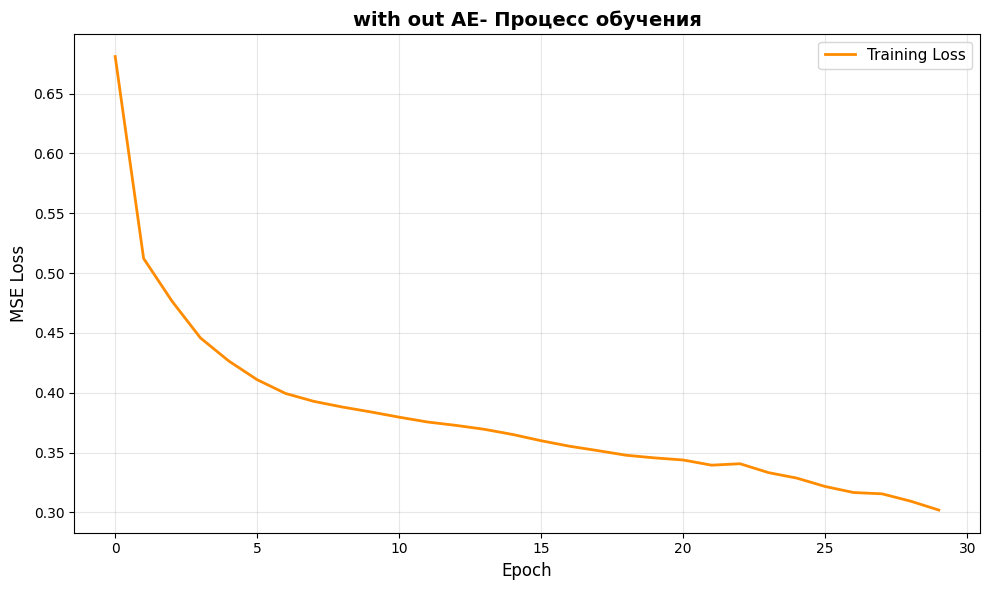

In [ ]:
epoch = 100
losses = []

for i in range(epoch):
    train_loss = trainer.train_epoch()
    losses.append(train_loss)
    print(f'epoch = {i+1} loss = {train_loss}')

plt.figure(figsize=(10, 6))
plt.plot(losses, linewidth=2, label='Training Loss', color='darkorange')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('with out AE- Процесс обучения', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# Переводим модель в режим оценки
model.eval()

# Списки для сбора всех предсказаний и истинных значений
all_predictions = []
all_probabilities = []
all_targets = []

# Отключаем градиенты для экономии памяти и ускорения
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(DEVICE)
        batch_y = batch_y.to(DEVICE)
        # Получаем предсказания модели
        outputs = model(batch_x)  # логиты
        
        # Конвертируем логиты в вероятности через sigmoid
        probabilities = torch.sigmoid(outputs)
        
        # Получаем бинарные предсказания (порог 0.5)
        predictions = (probabilities > 0.5).float()
        
        # Сохраняем результаты
        all_predictions.extend(predictions.cpu().numpy().flatten())
        all_probabilities.extend(probabilities.cpu().numpy().flatten())
        all_targets.extend(batch_y.cpu().numpy().flatten())

# Конвертируем в numpy массивы
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)
all_targets = np.array(all_targets)

print("="*60)
print("МЕТРИКИ КЛАССИФИКАЦИИ")
print("="*60)

# 1. Основные метрики
accuracy = accuracy_score(all_targets, all_predictions)
precision = precision_score(all_targets, all_predictions)
recall = recall_score(all_targets, all_predictions)
f1 = f1_score(all_targets, all_predictions)
roc_auc = roc_auc_score(all_targets, all_probabilities)

print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

# 2. Матрица ошибок (Confusion Matrix)
cm = confusion_matrix(all_targets, all_predictions)
print("\n" + "="*60)
print("МАТРИЦА ОШИБОК")
print("="*60)
print("                 Предсказано")
print("                 Neg   Pos")
print(f"Истина  Neg     {cm[0,0]:5d}  {cm[0,1]:5d}")
print(f"        Pos     {cm[1,0]:5d}  {cm[1,1]:5d}")
print()
print(f"True Negatives (TN):  {cm[0,0]}")
print(f"False Positives (FP): {cm[0,1]}")
print(f"False Negatives (FN): {cm[1,0]}")
print(f"True Positives (TP):  {cm[1,1]}")

# 3. Детальный отчет по классификации
print("\n" + "="*60)
print("ДЕТАЛЬНЫЙ ОТЧЕТ")
print("="*60)
print(classification_report(all_targets, all_predictions, 
                           target_names=['Класс 0', 'Класс 1']))


# 5. ROC-кривая
fpr, tpr, thresholds = roc_curve(all_targets, all_probabilities)


# 6. Анализ по порогам классификации
print("\n" + "="*60)
print("АНАЛИЗ ПО ПОРОГАМ КЛАССИФИКАЦИИ")
print("="*60)

thresholds_to_check = [0.3, 0.4, 0.5, 0.6, 0.7]
for threshold in thresholds_to_check:
    preds_thresh = (all_probabilities > threshold).astype(int)
    acc = accuracy_score(all_targets, preds_thresh)
    prec = precision_score(all_targets, preds_thresh)
    rec = recall_score(all_targets, preds_thresh)
    f1_thresh = f1_score(all_targets, preds_thresh)
    print(f"Threshold = {threshold:.1f}: Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1_thresh:.4f}")

# 7. Примеры инференса (предсказания для конкретных примеров)
print("\n" + "="*60)
print("ПРИМЕРЫ ИНФЕРЕНСА (первые 10 примеров из тестовой выборки)")
print("="*60)

model.eval()
with torch.no_grad():
    # Берем первые 10 примеров
    for i in range(min(10, len(test_ds))):
        x_sample, y_sample = test_ds[i]
        x_sample = x_sample.to(DEVICE)
        y_sample = y_sample.to(DEVICE)
        
        # Добавляем batch dimension
        x_sample = x_sample.unsqueeze(0)
        
        # Предсказание
        output = model(x_sample)
        probability = torch.sigmoid(output).item()
        prediction = 1 if probability > 0.5 else 0
        
        true_value = y_sample.item()
        
        # Цветной вывод для наглядности
        correct = "✅" if prediction == true_value else "❌"
        print(f"Пример {i+1:2d}: Истина={int(true_value)}, "
              f"Предсказание={prediction}, "
              f"Вероятность={probability:.4f} "
              f"{correct}")

# 8. Дополнительная статистика
print("\n" + "="*60)
print("ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА")
print("="*60)

# Распределение вероятностей
print(f"\nРаспределение предсказанных вероятностей:")
print(f"  Минимум:    {all_probabilities.min():.4f}")
print(f"  Максимум:   {all_probabilities.max():.4f}")
print(f"  Среднее:    {all_probabilities.mean():.4f}")
print(f"  Медиана:    {np.median(all_probabilities):.4f}")
print(f"  Станд. откл.: {all_probabilities.std():.4f}")

# Корректность по классам
correct_class_0 = np.sum((all_targets == 0) & (all_predictions == 0))
total_class_0 = np.sum(all_targets == 0)
correct_class_1 = np.sum((all_targets == 1) & (all_predictions == 1))
total_class_1 = np.sum(all_targets == 1)

print(f"\nТочность по классам:")
print(f"  Класс 0: {correct_class_0}/{total_class_0} = {correct_class_0/total_class_0*100:.2f}%")
print(f"  Класс 1: {correct_class_1}/{total_class_1} = {correct_class_1/total_class_1*100:.2f}%")

МЕТРИКИ КЛАССИФИКАЦИИ
Accuracy:  0.8688 (86.88%)
Precision: 0.8451 (84.51%)
Recall:    0.9760 (97.60%)
F1-Score:  0.9059
ROC-AUC:   0.9269

МАТРИЦА ОШИБОК
                 Предсказано
                 Neg   Pos
Истина  Neg       904    440
        Pos        59   2401

True Negatives (TN):  904
False Positives (FP): 440
False Negatives (FN): 59
True Positives (TP):  2401

ДЕТАЛЬНЫЙ ОТЧЕТ
              precision    recall  f1-score   support

     Класс 0       0.94      0.67      0.78      1344
     Класс 1       0.85      0.98      0.91      2460

    accuracy                           0.87      3804
   macro avg       0.89      0.82      0.84      3804
weighted avg       0.88      0.87      0.86      3804


АНАЛИЗ ПО ПОРОГАМ КЛАССИФИКАЦИИ
Threshold = 0.3: Accuracy=0.8573, Precision=0.8257, Recall=0.9878, F1=0.8995
Threshold = 0.4: Accuracy=0.8644, Precision=0.8361, Recall=0.9829, F1=0.9036
Threshold = 0.5: Accuracy=0.8688, Precision=0.8451, Recall=0.9760, F1=0.9059
Threshold = 0.6: A

In [ ]:
def encode_data(model, data, device):
    """
    Кодирует данные через обученный автоэнкодер
    
    Args:
        model: обученная модель AutoEncoder
        data: numpy array или DataFrame с данными
        device: устройство (cpu/cuda)
    
    Returns:
        encoded_data: сжатые данные (numpy array)
    """
    model.eval()  # Режим оценки
    
    # Конвертация в тензор
    if isinstance(data, pd.DataFrame):
        data_tensor = torch.from_numpy(data.values).float().to(device)
    else:
        data_tensor = torch.from_numpy(data).float().to(device)
    
    # Кодирование
    with torch.no_grad():  # Отключаем градиенты
        encoded_tensor = model.encode(data_tensor)
    
    # Возврат в numpy
    return encoded_tensor.cpu().numpy()

In [ ]:
X_train_encoded = encode_data(model_ae, x_train_scaled, DEVICE)
X_test_encoded = encode_data(model_ae, x_test_scaled, DEVICE)

train_ds_encode = TelescopeData(X_train_encoded , y_train)
test_ds_encode = TelescopeData(X_test_encoded, y_test)

train_loader_encode = DataLoader(train_ds_encode, batch_size=1024)
test_loader_encode = DataLoader(test_ds_encode, batch_size=1024)

X_test_encoded.shape

(3804, 4)

In [ ]:
model_w_ae = myModel_with_ae()
optimizer = AdamW(model_w_ae.parameters() ,lr=0.001)

trainer_w_ae = Trainer(model_w_ae,DEVICE, optimizer, train_loader_encode, test_loader_encode,weight_class_0)

epoch = 1 loss = 0.7449954708417257
epoch = 2 loss = 0.6029455860455831
epoch = 3 loss = 0.5748537659645081
epoch = 4 loss = 0.5593908786773681
epoch = 5 loss = 0.5510021408398946
epoch = 6 loss = 0.5457914272944132
epoch = 7 loss = 0.5436117072900136
epoch = 8 loss = 0.5420159796873728
epoch = 9 loss = 0.5395659685134888
epoch = 10 loss = 0.5384485205014546
epoch = 11 loss = 0.5379352509975434
epoch = 12 loss = 0.5373281260331472
epoch = 13 loss = 0.5378022452195486
epoch = 14 loss = 0.5391820907592774
epoch = 15 loss = 0.5364479740460714
epoch = 16 loss = 0.5309423883756001
epoch = 17 loss = 0.5280675729115804
epoch = 18 loss = 0.5267496963342031
epoch = 19 loss = 0.5246002634366354
epoch = 20 loss = 0.5230956753094991
epoch = 21 loss = 0.5221784631411235
epoch = 22 loss = 0.520971824725469
epoch = 23 loss = 0.5204481661319733
epoch = 24 loss = 0.5205413679281871
epoch = 25 loss = 0.5205171644687653
epoch = 26 loss = 0.5195383628209432
epoch = 27 loss = 0.5181424558162689
epoch = 28 

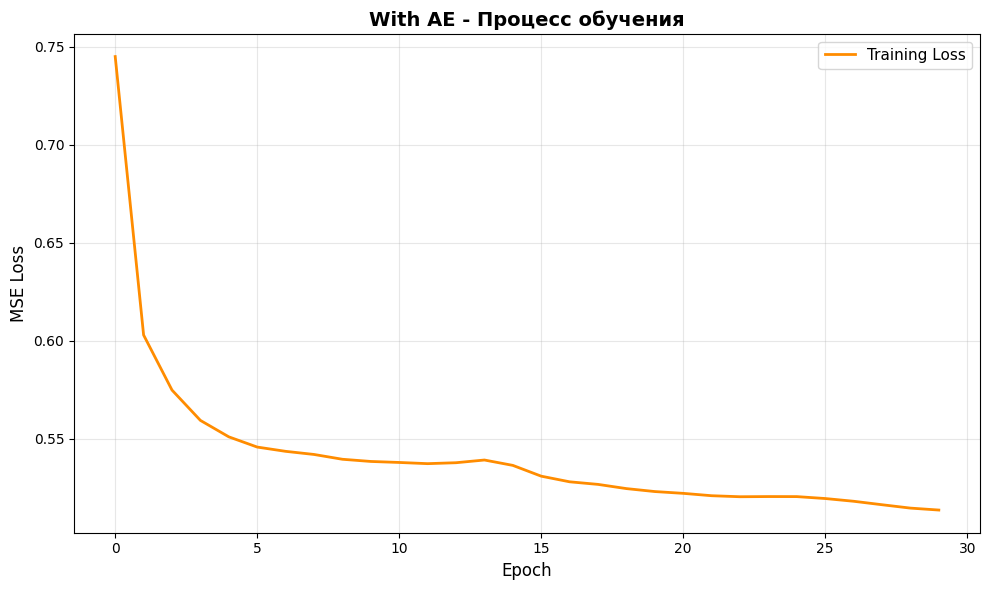

In [ ]:
epoch = 100
losses = []

for i in range(epoch):
    train_loss = trainer_w_ae.train_epoch()
    losses.append(train_loss)
    print(f'epoch = {i+1} loss = {train_loss}')

plt.figure(figsize=(10, 6))
plt.plot(losses, linewidth=2, label='Training Loss', color='darkorange')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('With AE - Процесс обучения', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# Переводим модель в режим оценки
model_w_ae.eval()

# Списки для сбора всех предсказаний и истинных значений
all_predictions = []
all_probabilities = []
all_targets = []

# Отключаем градиенты для экономии памяти и ускорения
with torch.no_grad():
    for batch_x, batch_y in test_loader_encode:
        batch_x = batch_x.to(DEVICE)
        batch_y = batch_y.to(DEVICE)
        # Получаем предсказания модели
        outputs = model_w_ae(batch_x)  # логиты
        
        # Конвертируем логиты в вероятности через sigmoid
        probabilities = torch.sigmoid(outputs)
        
        # Получаем бинарные предсказания (порог 0.5)
        predictions = (probabilities > 0.5).float()
        
        # Сохраняем результаты
        all_predictions.extend(predictions.cpu().numpy().flatten())
        all_probabilities.extend(probabilities.cpu().numpy().flatten())
        all_targets.extend(batch_y.cpu().numpy().flatten())

# Конвертируем в numpy массивы
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)
all_targets = np.array(all_targets)

print("="*60)
print("МЕТРИКИ КЛАССИФИКАЦИИ")
print("="*60)

# 1. Основные метрики
accuracy = accuracy_score(all_targets, all_predictions)
precision = precision_score(all_targets, all_predictions)
recall = recall_score(all_targets, all_predictions)
f1 = f1_score(all_targets, all_predictions)
roc_auc = roc_auc_score(all_targets, all_probabilities)

print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

# 2. Матрица ошибок (Confusion Matrix)
cm = confusion_matrix(all_targets, all_predictions)
print("\n" + "="*60)
print("МАТРИЦА ОШИБОК")
print("="*60)
print("                 Предсказано")
print("                 Neg   Pos")
print(f"Истина  Neg     {cm[0,0]:5d}  {cm[0,1]:5d}")
print(f"        Pos     {cm[1,0]:5d}  {cm[1,1]:5d}")
print()
print(f"True Negatives (TN):  {cm[0,0]}")
print(f"False Positives (FP): {cm[0,1]}")
print(f"False Negatives (FN): {cm[1,0]}")
print(f"True Positives (TP):  {cm[1,1]}")

# 3. Детальный отчет по классификации
print("\n" + "="*60)
print("ДЕТАЛЬНЫЙ ОТЧЕТ")
print("="*60)
print(classification_report(all_targets, all_predictions, 
                           target_names=['Класс 0', 'Класс 1']))


# 5. ROC-кривая
fpr, tpr, thresholds = roc_curve(all_targets, all_probabilities)


# 6. Анализ по порогам классификации
print("\n" + "="*60)
print("АНАЛИЗ ПО ПОРОГАМ КЛАССИФИКАЦИИ")
print("="*60)

thresholds_to_check = [0.3, 0.4, 0.5, 0.6, 0.7]
for threshold in thresholds_to_check:
    preds_thresh = (all_probabilities > threshold).astype(int)
    acc = accuracy_score(all_targets, preds_thresh)
    prec = precision_score(all_targets, preds_thresh)
    rec = recall_score(all_targets, preds_thresh)
    f1_thresh = f1_score(all_targets, preds_thresh)
    print(f"Threshold = {threshold:.1f}: Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1_thresh:.4f}")

# 7. Примеры инференса (предсказания для конкретных примеров)
print("\n" + "="*60)
print("ПРИМЕРЫ ИНФЕРЕНСА (первые 10 примеров из тестовой выборки)")
print("="*60)

model_w_ae.eval()
with torch.no_grad():
    # Берем первые 10 примеров
    for i in range(min(10, len(test_ds_encode))):
        x_sample, y_sample = test_ds_encode[i]
        x_sample = x_sample.to(DEVICE)
        y_sample = y_sample.to(DEVICE)
        
        # Добавляем batch dimension
        x_sample = x_sample.unsqueeze(0)
        
        # Предсказание
        output = model_w_ae(x_sample)
        probability = torch.sigmoid(output).item()
        prediction = 1 if probability > 0.5 else 0
        
        true_value = y_sample.item()
        
        # Цветной вывод для наглядности
        correct = "✅" if prediction == true_value else "❌"
        print(f"Пример {i+1:2d}: Истина={int(true_value)}, "
              f"Предсказание={prediction}, "
              f"Вероятность={probability:.4f} "
              f"{correct}")

# 8. Дополнительная статистика
print("\n" + "="*60)
print("ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА")
print("="*60)

# Распределение вероятностей
print(f"\nРаспределение предсказанных вероятностей:")
print(f"  Минимум:    {all_probabilities.min():.4f}")
print(f"  Максимум:   {all_probabilities.max():.4f}")
print(f"  Среднее:    {all_probabilities.mean():.4f}")
print(f"  Медиана:    {np.median(all_probabilities):.4f}")
print(f"  Станд. откл.: {all_probabilities.std():.4f}")

# Корректность по классам
correct_class_0 = np.sum((all_targets == 0) & (all_predictions == 0))
total_class_0 = np.sum(all_targets == 0)
correct_class_1 = np.sum((all_targets == 1) & (all_predictions == 1))
total_class_1 = np.sum(all_targets == 1)

print(f"\nТочность по классам:")
print(f"  Класс 0: {correct_class_0}/{total_class_0} = {correct_class_0/total_class_0*100:.2f}%")
print(f"  Класс 1: {correct_class_1}/{total_class_1} = {correct_class_1/total_class_1*100:.2f}%")

МЕТРИКИ КЛАССИФИКАЦИИ
Accuracy:  0.8034 (80.34%)
Precision: 0.7865 (78.65%)
Recall:    0.9553 (95.53%)
F1-Score:  0.8627
ROC-AUC:   0.8622

МАТРИЦА ОШИБОК
                 Предсказано
                 Neg   Pos
Истина  Neg       706    638
        Pos       110   2350

True Negatives (TN):  706
False Positives (FP): 638
False Negatives (FN): 110
True Positives (TP):  2350

ДЕТАЛЬНЫЙ ОТЧЕТ
              precision    recall  f1-score   support

     Класс 0       0.87      0.53      0.65      1344
     Класс 1       0.79      0.96      0.86      2460

    accuracy                           0.80      3804
   macro avg       0.83      0.74      0.76      3804
weighted avg       0.81      0.80      0.79      3804


АНАЛИЗ ПО ПОРОГАМ КЛАССИФИКАЦИИ
Threshold = 0.3: Accuracy=0.7755, Precision=0.7471, Recall=0.9870, F1=0.8504
Threshold = 0.4: Accuracy=0.7876, Precision=0.7636, Recall=0.9728, F1=0.8556
Threshold = 0.5: Accuracy=0.8034, Precision=0.7865, Recall=0.9553, F1=0.8627
Threshold = 0.6: 

Метрики качества реконструкции:
MSE: 0.072791
MAE: 0.184810
RMSE: 0.269798
R²: 0.927778
MAPE: 132.55%
Лучший признак MSE: 0.028659
Худший признак MSE: 0.110092


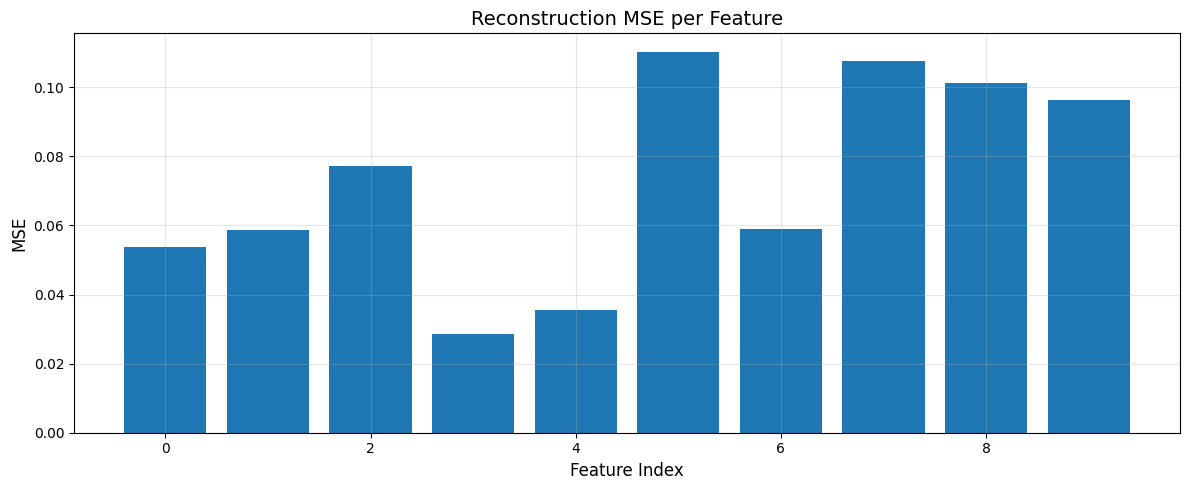

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calculate_reconstruction_metrics(model, test_loader, device='cuda'):
    """
    Расчет различных метрик качества реконструкции
    """
    model.eval()
    all_originals = []
    all_reconstructed = []
    
    with torch.no_grad():
        for data, _ in test_loader:
            data = data.to(device)
            reconstructed = model(data)
            
            all_originals.append(data.cpu().numpy())
            all_reconstructed.append(reconstructed.cpu().numpy())
    
    # Объединяем все батчи
    originals = np.vstack(all_originals)
    reconstructed = np.vstack(all_reconstructed)
    
    # Метрики
    metrics = {}
    
    # MSE (среднеквадратичная ошибка)
    metrics['MSE'] = mean_squared_error(originals.flatten(), reconstructed.flatten())
    
    # MAE (средняя абсолютная ошибка)
    metrics['MAE'] = mean_absolute_error(originals.flatten(), reconstructed.flatten())
    
    # RMSE (корень из среднеквадратичной ошибки)
    metrics['RMSE'] = np.sqrt(metrics['MSE'])
    
    # R² score (коэффициент детерминации)
    metrics['R2'] = r2_score(originals.flatten(), reconstructed.flatten())
    
    # MAPE (средняя абсолютная процентная ошибка)
    # Добавляем маленькое число чтобы избежать деления на ноль
    epsilon = 1e-10
    mape = np.mean(np.abs((originals - reconstructed) / (np.abs(originals) + epsilon))) * 100
    metrics['MAPE'] = mape
    
    # Попиксельные метрики
    per_feature_mse = np.mean((originals - reconstructed) ** 2, axis=0)
    metrics['per_feature_mse'] = per_feature_mse
    metrics['best_feature_mse'] = np.min(per_feature_mse)
    metrics['worst_feature_mse'] = np.max(per_feature_mse)
    
    return metrics, originals, reconstructed

# Использование
metrics, originals, reconstructed = calculate_reconstruction_metrics(model_ae, test_loader, DEVICE)

print("Метрики качества реконструкции:")
print(f"MSE: {metrics['MSE']:.6f}")
print(f"MAE: {metrics['MAE']:.6f}")
print(f"RMSE: {metrics['RMSE']:.6f}")
print(f"R²: {metrics['R2']:.6f}")
print(f"MAPE: {metrics['MAPE']:.2f}%")
print(f"Лучший признак MSE: {metrics['best_feature_mse']:.6f}")
print(f"Худший признак MSE: {metrics['worst_feature_mse']:.6f}")

# Визуализация MSE по признакам
plt.figure(figsize=(12, 5))
plt.bar(range(len(metrics['per_feature_mse'])), metrics['per_feature_mse'])
plt.xlabel('Feature Index', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('Reconstruction MSE per Feature', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()